# Loading all the libraries

In [967]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d

sn.set(font_scale=1.4)#for label size

from matplotlib.ticker import MaxNLocator
%matplotlib inline

In [968]:
#fileprefix = "../CardStock/output/TraditionalTestbedOld/"
fileprefix = "../CardStock/output/"

cbbPalette = ["#D55E00", "#009E73", "#0072B2", "#000000", "#CC79A7" ]


# Game Information

Each experiment should be on a different line in "games".

In [927]:
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"Rummy","name":"Rummy", "player":2},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skittgube", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},

#    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
#    {"game":"Coloretto","name":"Coloretto", "player":4},
#    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Escoba","name":"Escoba", "player":2},
#    {"game":"LostCities","name":"Lost Cities", "player":2},
#    {"game":"LAMA","name":"LAMA", "player":4},
#    {"game":"NoThanks","name":"No Thanks", "player":4},
#    {"game":"PageOne","name":"Page One", "player":3},
#    {"game":"SaneEights","name":"Sane Eights", "player":4},
#    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
#    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
#    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
#    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
#    {"game":"Pairs","name":"Pairs", "player":3},
#    {"game":"Clocktowers","name":"Clocktowers", "player":2},
#    {"game":"Briscola","name":"Briscola", "player":2},
#    {"game":"Trifle","name":"Trifle", "player":2},
#    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe

,game,name,player
0,Agram,Agram,3
1,Blackjack,Blackjack,1
2,CrazyEights,Crazy Eights,3
3,Cribbage,Cribbage,2
4,Cuckoo,Cuckoo,6
5,Euchre,Euchre,4
6,GoFish,Go Fish,4
7,GolfSix,Golf-6,4
8,GOPS,Goofspiel,2
9,Hearts,Hearts,4


In [1026]:
games = [

    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
    {"game":"Coloretto","name":"Coloretto", "player":4},
    {"game":"Comet","name":"Comet", "player":2},
    {"game":"Escoba","name":"Escoba", "player":2},
    {"game":"LostCities","name":"Lost Cities", "player":2},
    {"game":"LAMA","name":"LAMA", "player":4},
    {"game":"NoThanks","name":"No Thanks", "player":4},
    {"game":"PageOne","name":"Page One", "player":3},
    {"game":"SaneEights","name":"Sane Eights", "player":4},
    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
    {"game":"Pairs","name":"Pairs", "player":3},
    {"game":"Clocktowers","name":"Clocktowers", "player":2},
    {"game":"Briscola","name":"Briscola", "player":2},
    {"game":"Trifle","name":"Trifle", "player":2},
    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    {"game":"FoxInTheForest","name":"The Fox in the Forest", "player":2},
    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe

,game,name,player
0,ShastaSam,Shasta Sam,2
1,Coloretto,Coloretto,4
2,Comet,Comet,2
3,Escoba,Escoba,2
4,LostCities,Lost Cities,2
5,LAMA,LAMA,4
6,NoThanks,No Thanks,4
7,PageOne,Page One,3
8,SaneEights,Sane Eights,4
9,Simon'sCat,Simon's Cat,4


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [1027]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    gf["game"] = row["game"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    choiceframe = pd.concat([choiceframe, gf])

In [1028]:
choiceframe

,game,numPlayers,ai,run,move,player,choices,choice,time
0,ShastaSam,2,RR,1,1,1,6,6,0.0
1,ShastaSam,2,RR,1,2,2,1,1,0.0
2,ShastaSam,2,RR,1,3,2,6,5,0.0
3,ShastaSam,2,RR,1,4,1,1,1,0.0
4,ShastaSam,2,RR,1,5,1,6,2,0.0
...,...,...,...,...,...,...,...,...,...
5195,FoxInTheForest,2,PR,100,48,1,2,1,0.0
5196,FoxInTheForest,2,PR,100,49,2,1,1,0.0
5197,FoxInTheForest,2,PR,100,50,2,1,1,0.0
5198,FoxInTheForest,2,PR,100,51,1,1,1,1.0


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [1029]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    print(row["game"])
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    if count == 0:
        print(row["game"])
    cseq.append(convergence / count)

ShastaSam
Coloretto
Comet
Escoba
LostCities
LAMA
NoThanks
PageOne
SaneEights
Simon'sCat
SpiteMalice
TurnTheTide
BottleImp
Pairs
Clocktowers
Briscola
Trifle
SixNimmt
FoxInTheForest


In [1030]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,convergence
0,ShastaSam,Shasta Sam,2,0.518289
1,Coloretto,Coloretto,4,0.502310
2,Comet,Comet,2,0.563943
3,Escoba,Escoba,2,0.501455
4,LostCities,Lost Cities,2,0.502988
5,LAMA,LAMA,4,0.587322
6,NoThanks,No Thanks,4,0.500000
7,PageOne,Page One,3,0.517691
8,SaneEights,Sane Eights,4,0.499488
9,Simon'sCat,Simon's Cat,4,0.540589


## Plotting all games

This plot shows the branching factors over all of the games in the testbed.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


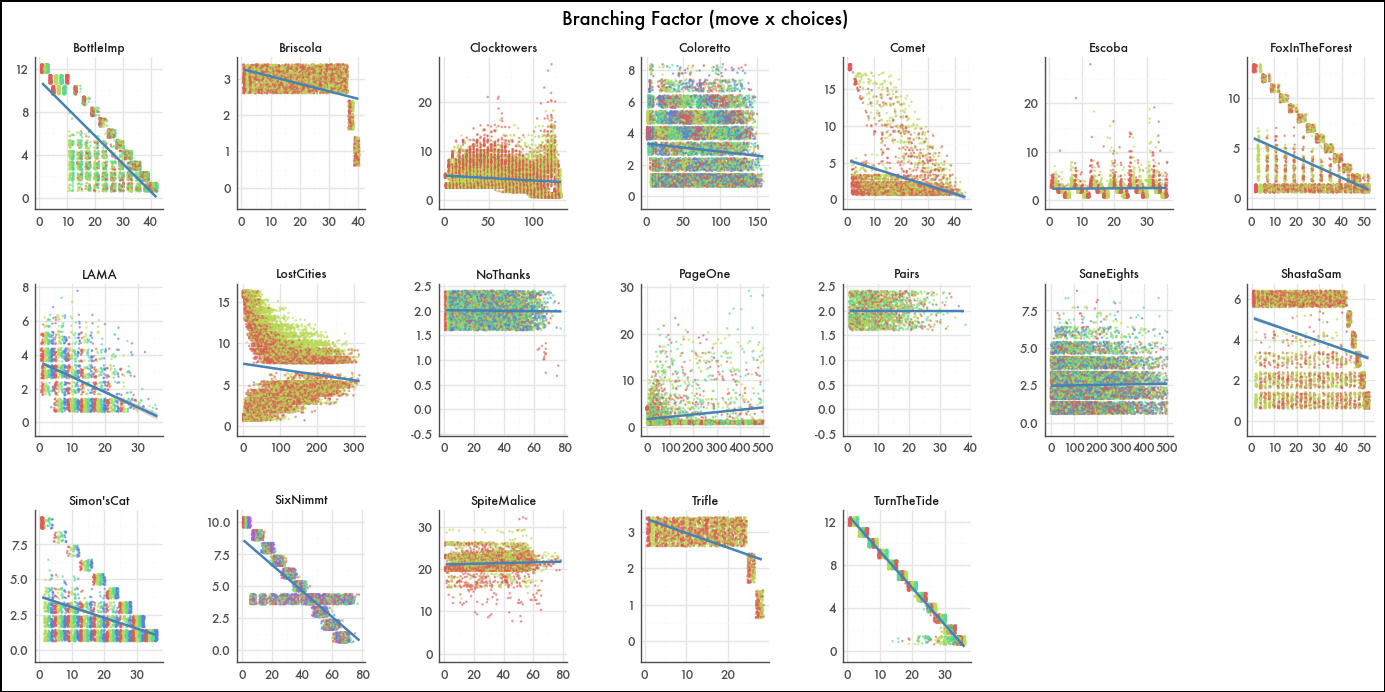

In [1031]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


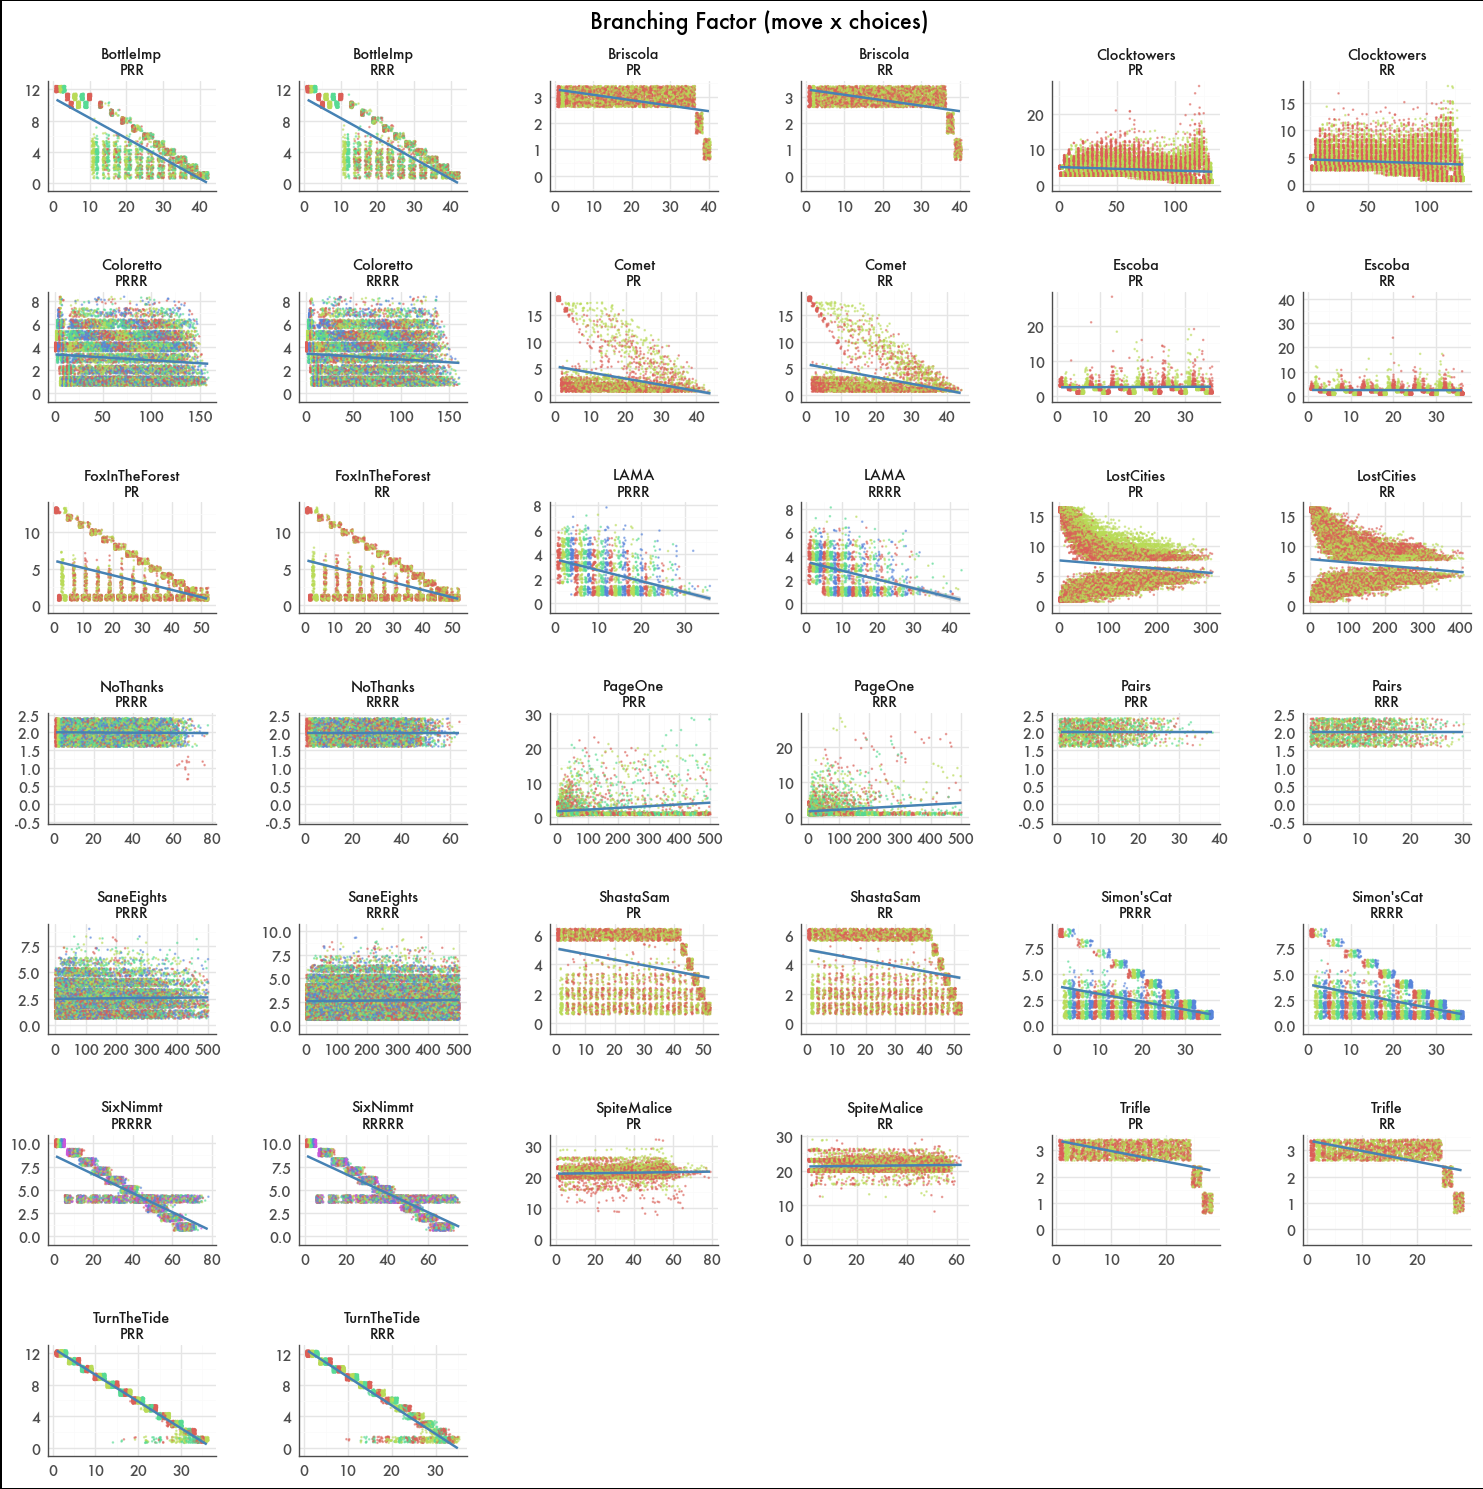

In [1033]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [1034]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,BottleImp,50.5,42.00
1,Briscola,50.5,40.00
2,Clocktowers,50.5,132.00
3,Coloretto,50.5,133.54
4,Comet,50.5,38.31
5,Escoba,50.5,36.00
6,FoxInTheForest,50.5,52.00
7,LAMA,50.5,17.87
8,LostCities,50.5,285.62
9,NoThanks,50.5,47.39


In [1035]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [1036]:
gameframe

,game,name,player,convergence,move
0,ShastaSam,Shasta Sam,2,0.518289,52.00
1,Coloretto,Coloretto,4,0.502310,133.54
2,Comet,Comet,2,0.563943,38.31
3,Escoba,Escoba,2,0.501455,36.00
4,LostCities,Lost Cities,2,0.502988,285.62
5,LAMA,LAMA,4,0.587322,17.87
6,NoThanks,No Thanks,4,0.500000,47.39
7,PageOne,Page One,3,0.517691,50.90
8,SaneEights,Sane Eights,4,0.499488,327.34
9,Simon'sCat,Simon's Cat,4,0.540589,36.00


In [1037]:
lengthf.dtypes

game     object
move    float64
dtype: object

# Fairness

For random games, we want to look at the distribution of scores across the players.

In [1038]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["ai"] = "PIMC"
    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

,game,numPlayers,ai,run,player,score,rank,time
0,ShastaSam,2,Random,1,1,3,1,35.0
1,ShastaSam,2,Random,1,2,1,2,35.0
2,ShastaSam,2,Random,2,1,2,1,33.0
3,ShastaSam,2,Random,2,2,2,1,33.0
4,ShastaSam,2,Random,3,1,2,1,31.0
...,...,...,...,...,...,...,...,...
195,FoxInTheForest,2,PIMC,98,2,6,1,868.0
196,FoxInTheForest,2,PIMC,99,1,8,1,763.0
197,FoxInTheForest,2,PIMC,99,2,3,2,763.0
198,FoxInTheForest,2,PIMC,100,1,7,1,619.0


In [1064]:
resultsframe[resultsframe["score"] > 8]

,game,numPlayers,ai,run,player,score,rank,time
1,Coloretto,4,Random,1,2,30,1,39.0
2,Coloretto,4,Random,1,3,14,3,39.0
3,Coloretto,4,Random,1,4,15,2,39.0
5,Coloretto,4,Random,2,2,23,1,40.0
7,Coloretto,4,Random,2,4,11,2,40.0
...,...,...,...,...,...,...,...,...
59,FoxInTheForest,2,PIMC,30,2,9,1,736.0
90,FoxInTheForest,2,PIMC,46,1,9,1,749.0
114,FoxInTheForest,2,PIMC,58,1,9,1,710.0
172,FoxInTheForest,2,PIMC,87,1,9,1,781.0


In [1039]:
rf2 = resultsframe.groupby(['game', 'player', 'rank', 'ai'], as_index=False).count()

In [1040]:
rf2

,game,player,rank,ai,numPlayers,run,score,time
0,BottleImp,1,1,PIMC,92,92,92,0
1,BottleImp,1,1,Random,27,27,27,27
2,BottleImp,1,2,PIMC,5,5,5,0
3,BottleImp,1,2,Random,33,33,33,33
4,BottleImp,1,3,PIMC,3,3,3,0
...,...,...,...,...,...,...,...,...
339,TurnTheTide,3,1,Random,39,39,39,39
340,TurnTheTide,3,2,PIMC,50,50,50,0
341,TurnTheTide,3,2,Random,50,50,50,50
342,TurnTheTide,3,3,PIMC,29,29,29,0


In [1041]:
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")]
rf3

,game,player,rank,ai,numPlayers,run,score,time
0,BottleImp,1,1,PIMC,92,92,92,0
1,BottleImp,1,1,Random,27,27,27,27
18,Briscola,1,1,PIMC,85,85,85,85
19,Briscola,1,1,Random,55,55,55,55
26,Clocktowers,1,1,PIMC,100,100,100,0
27,Clocktowers,1,1,Random,52,52,52,52
32,Coloretto,1,1,PIMC,82,82,82,0
33,Coloretto,1,1,Random,19,19,19,19
63,Comet,1,1,PIMC,74,74,74,0
64,Comet,1,1,Random,49,49,49,49


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


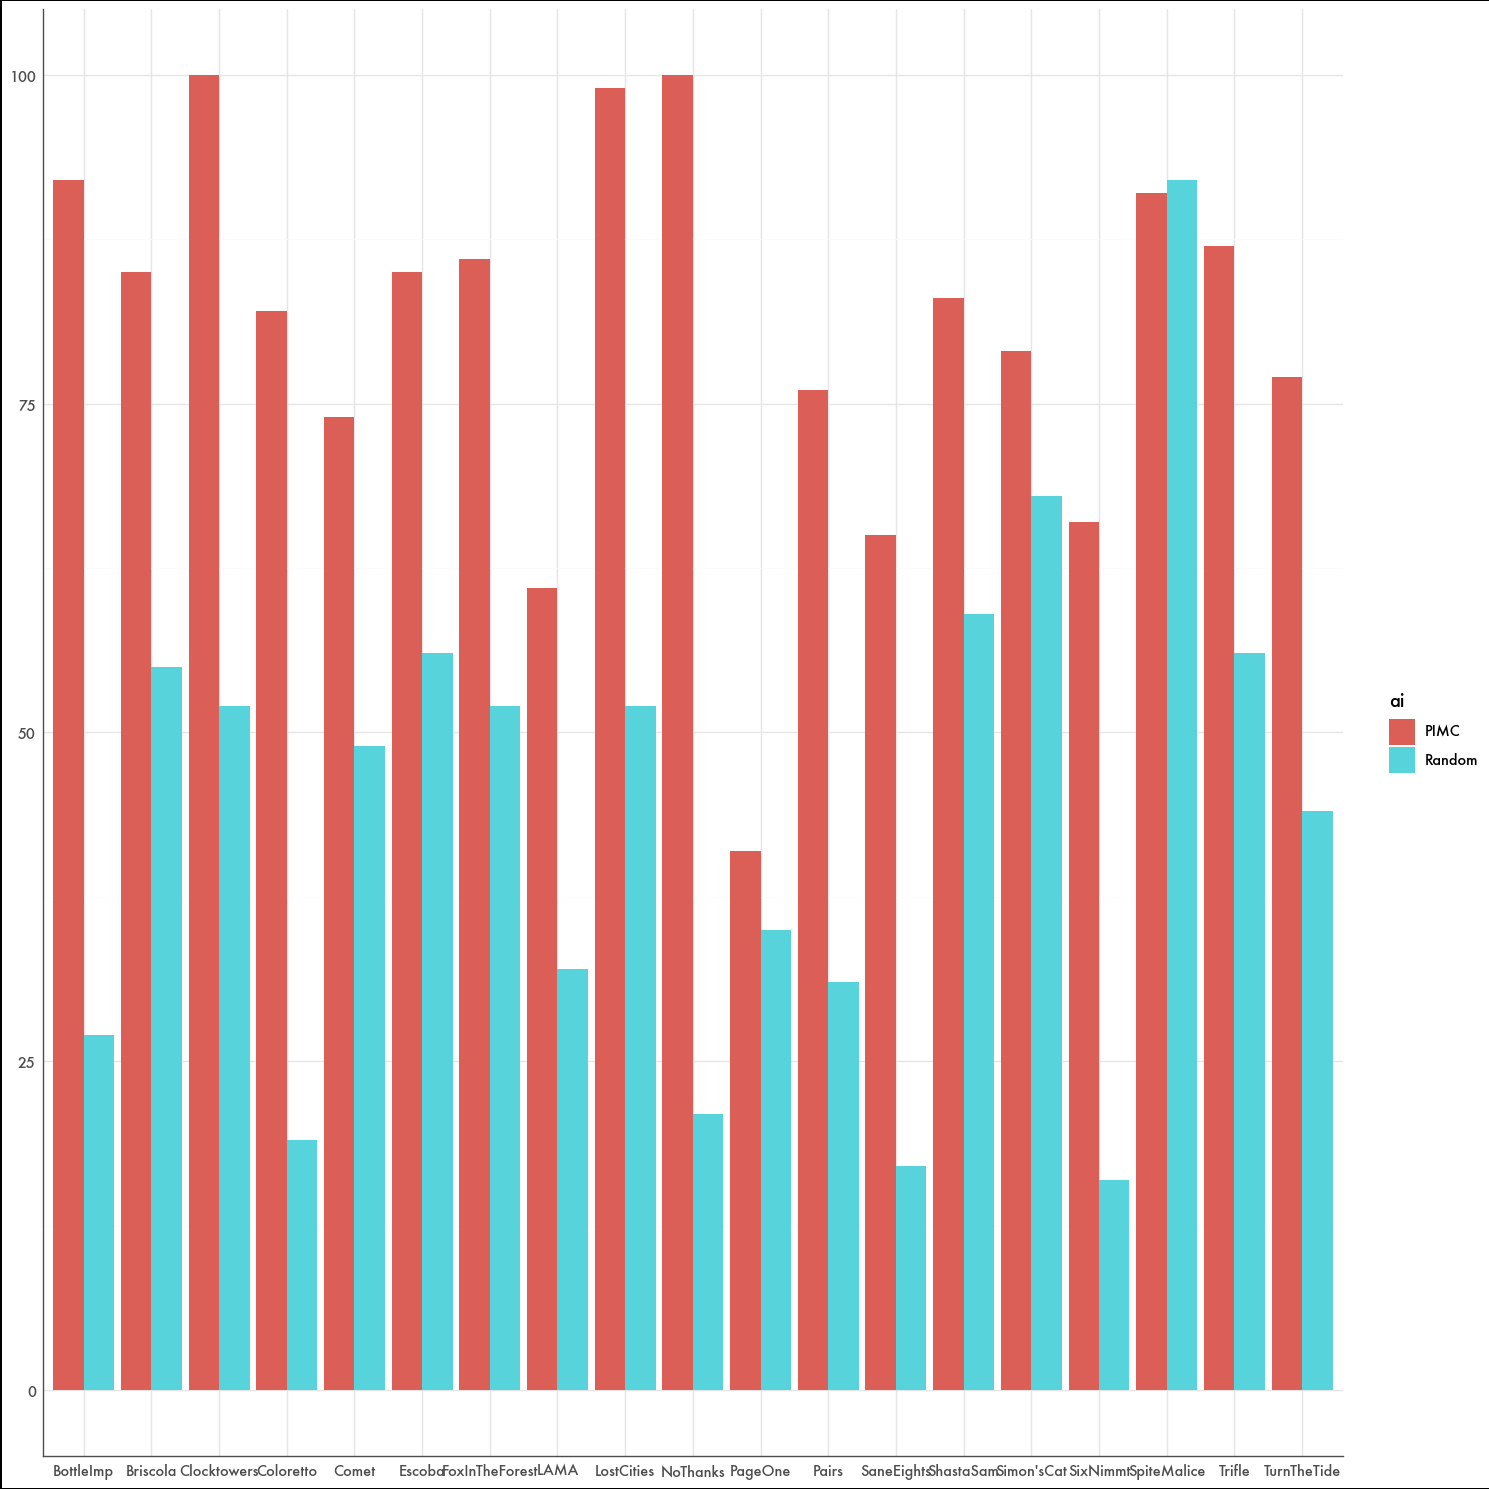

In [1042]:
rplot = (ggplot(rf3, aes("game", "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


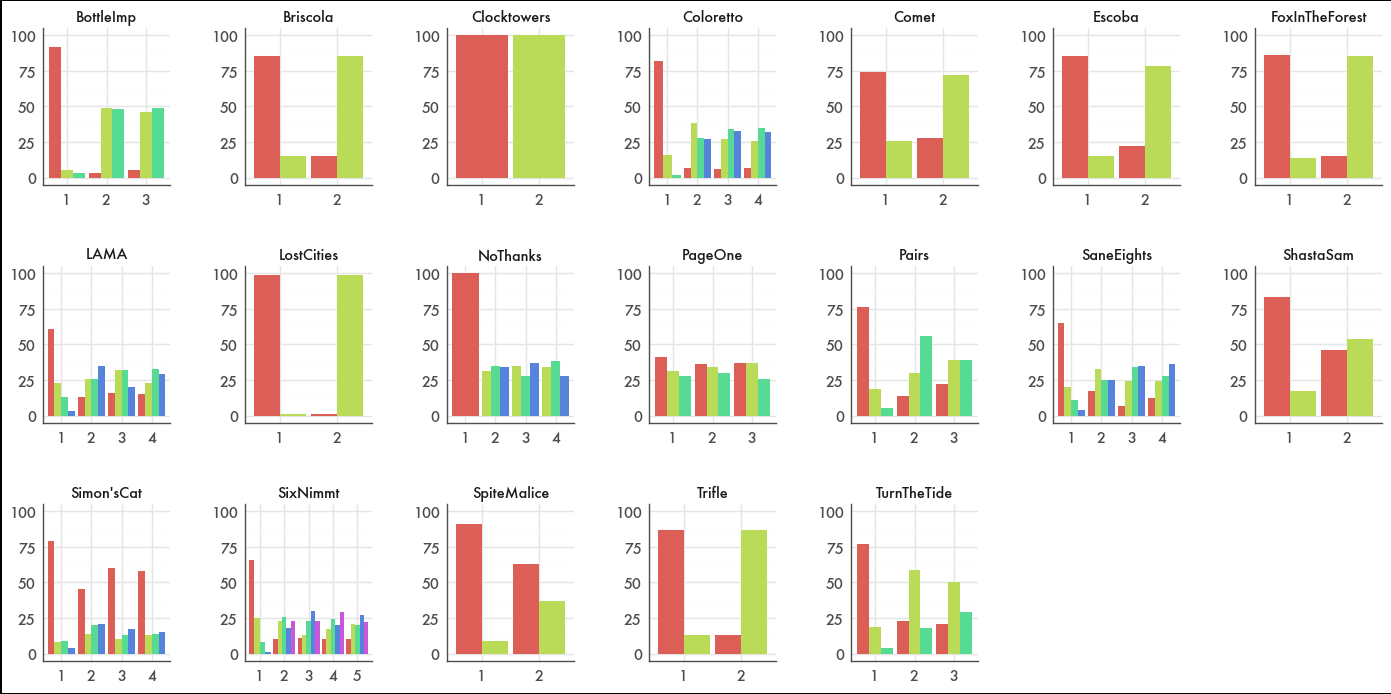

In [1043]:
rplot = (ggplot(rf2[rf2["ai"]=="PIMC"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


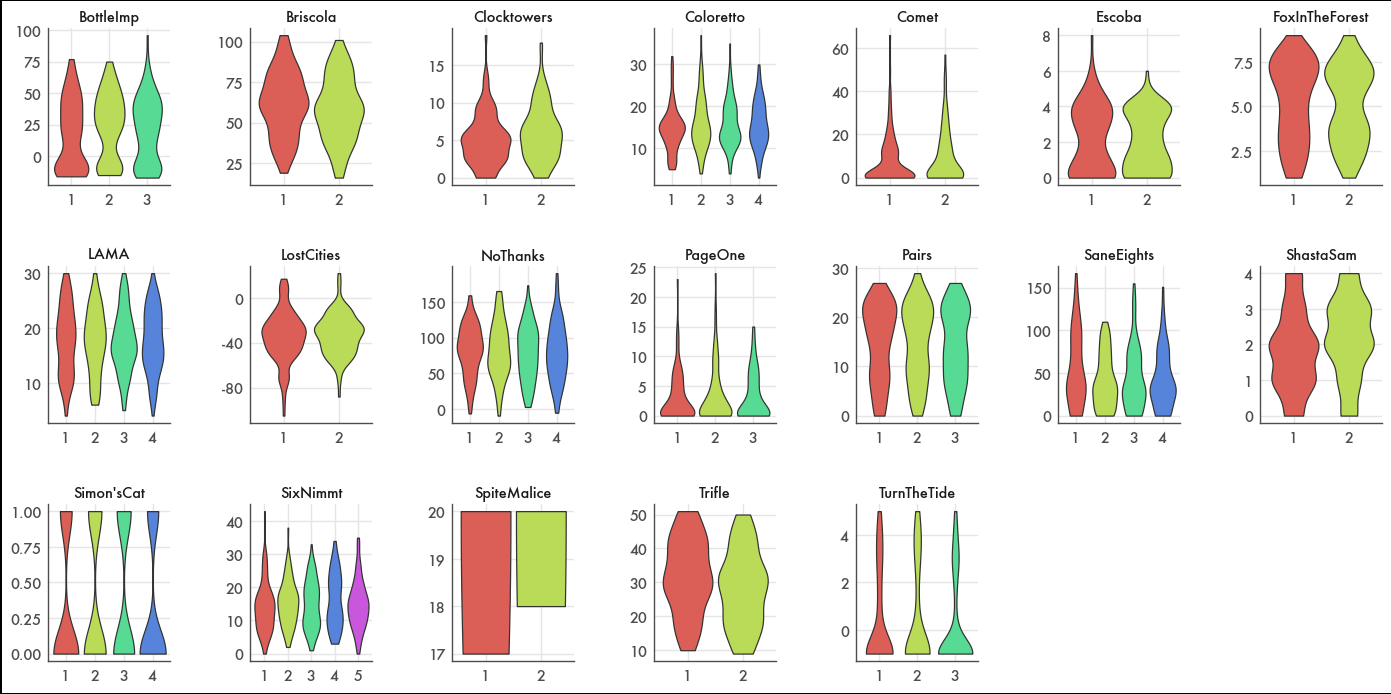

In [1044]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("R")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("Scores.png")
splot.show()

In [1045]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("P")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


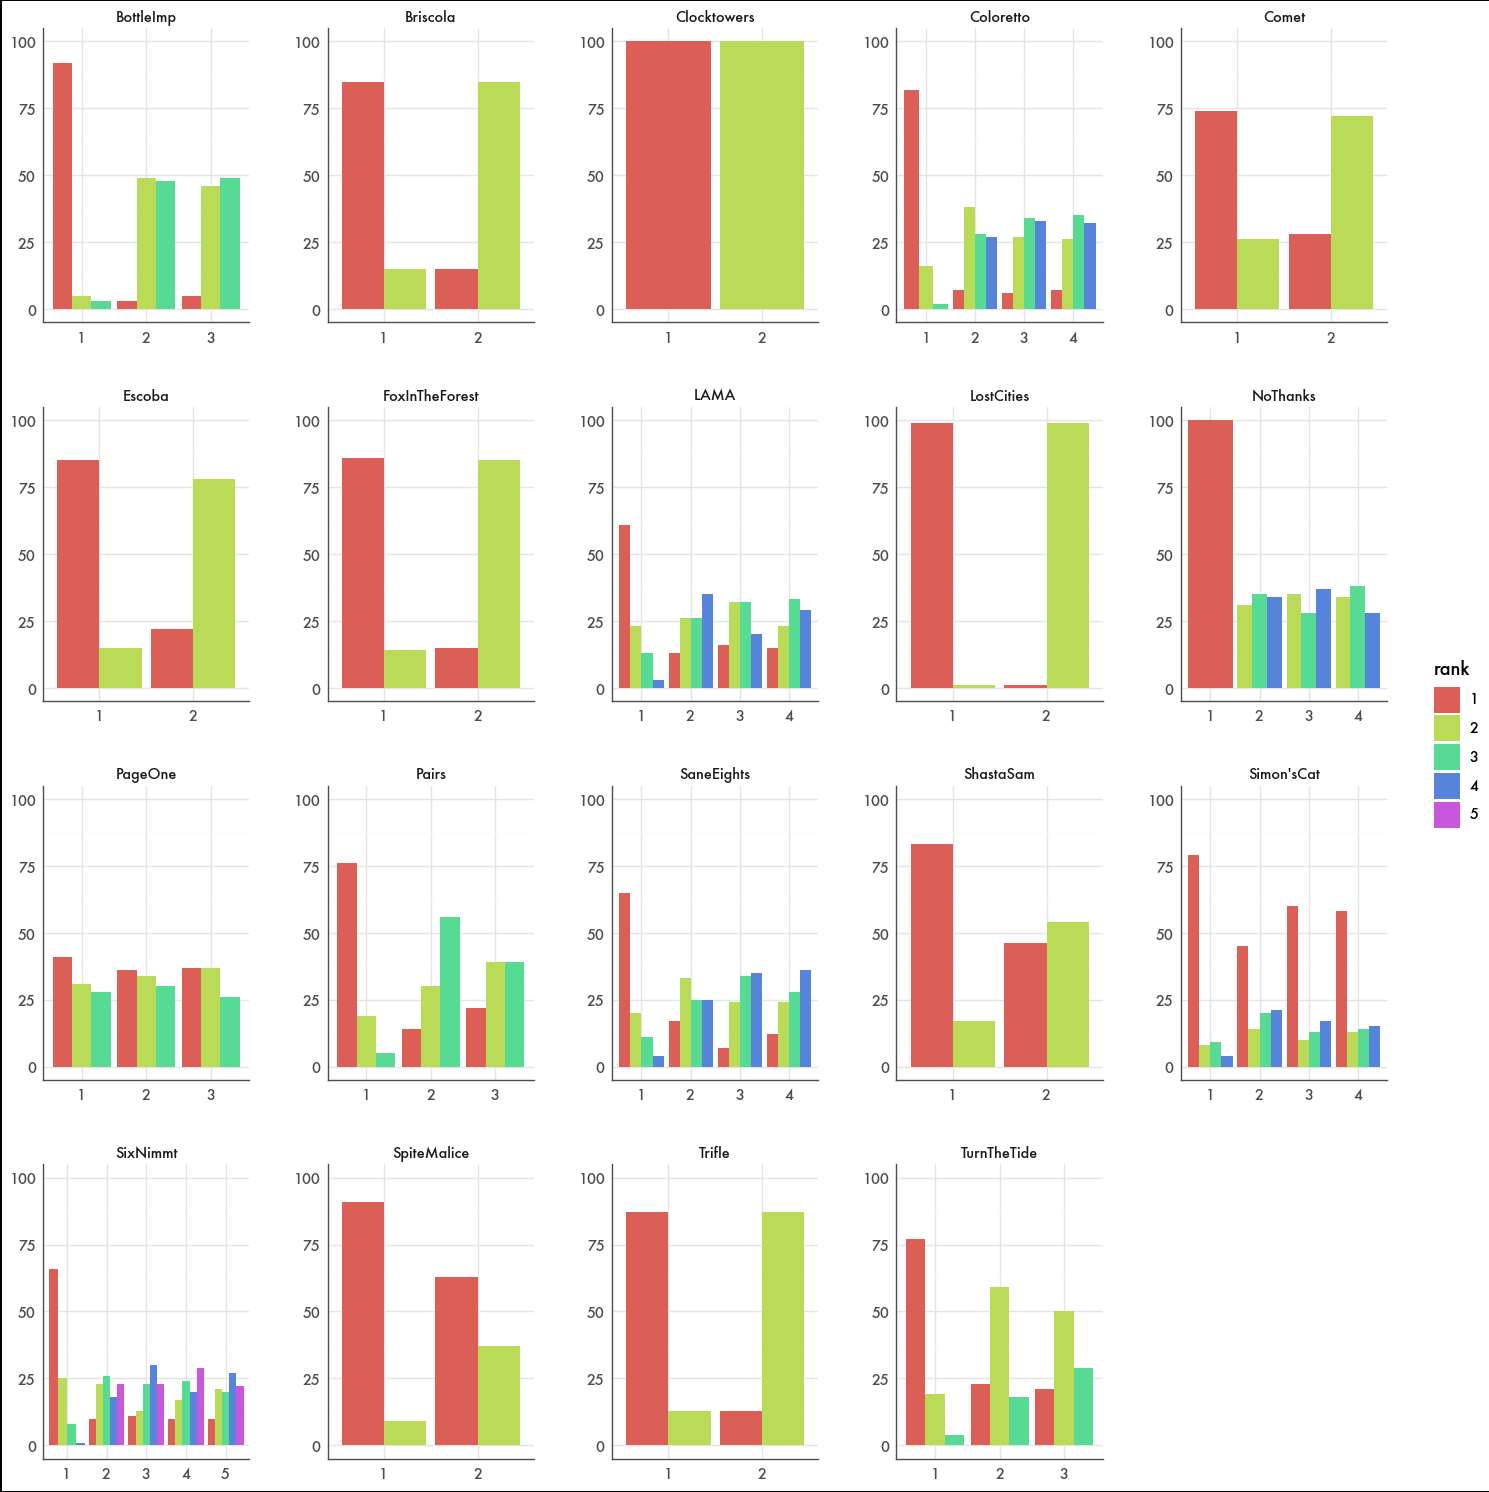

In [1046]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 15 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


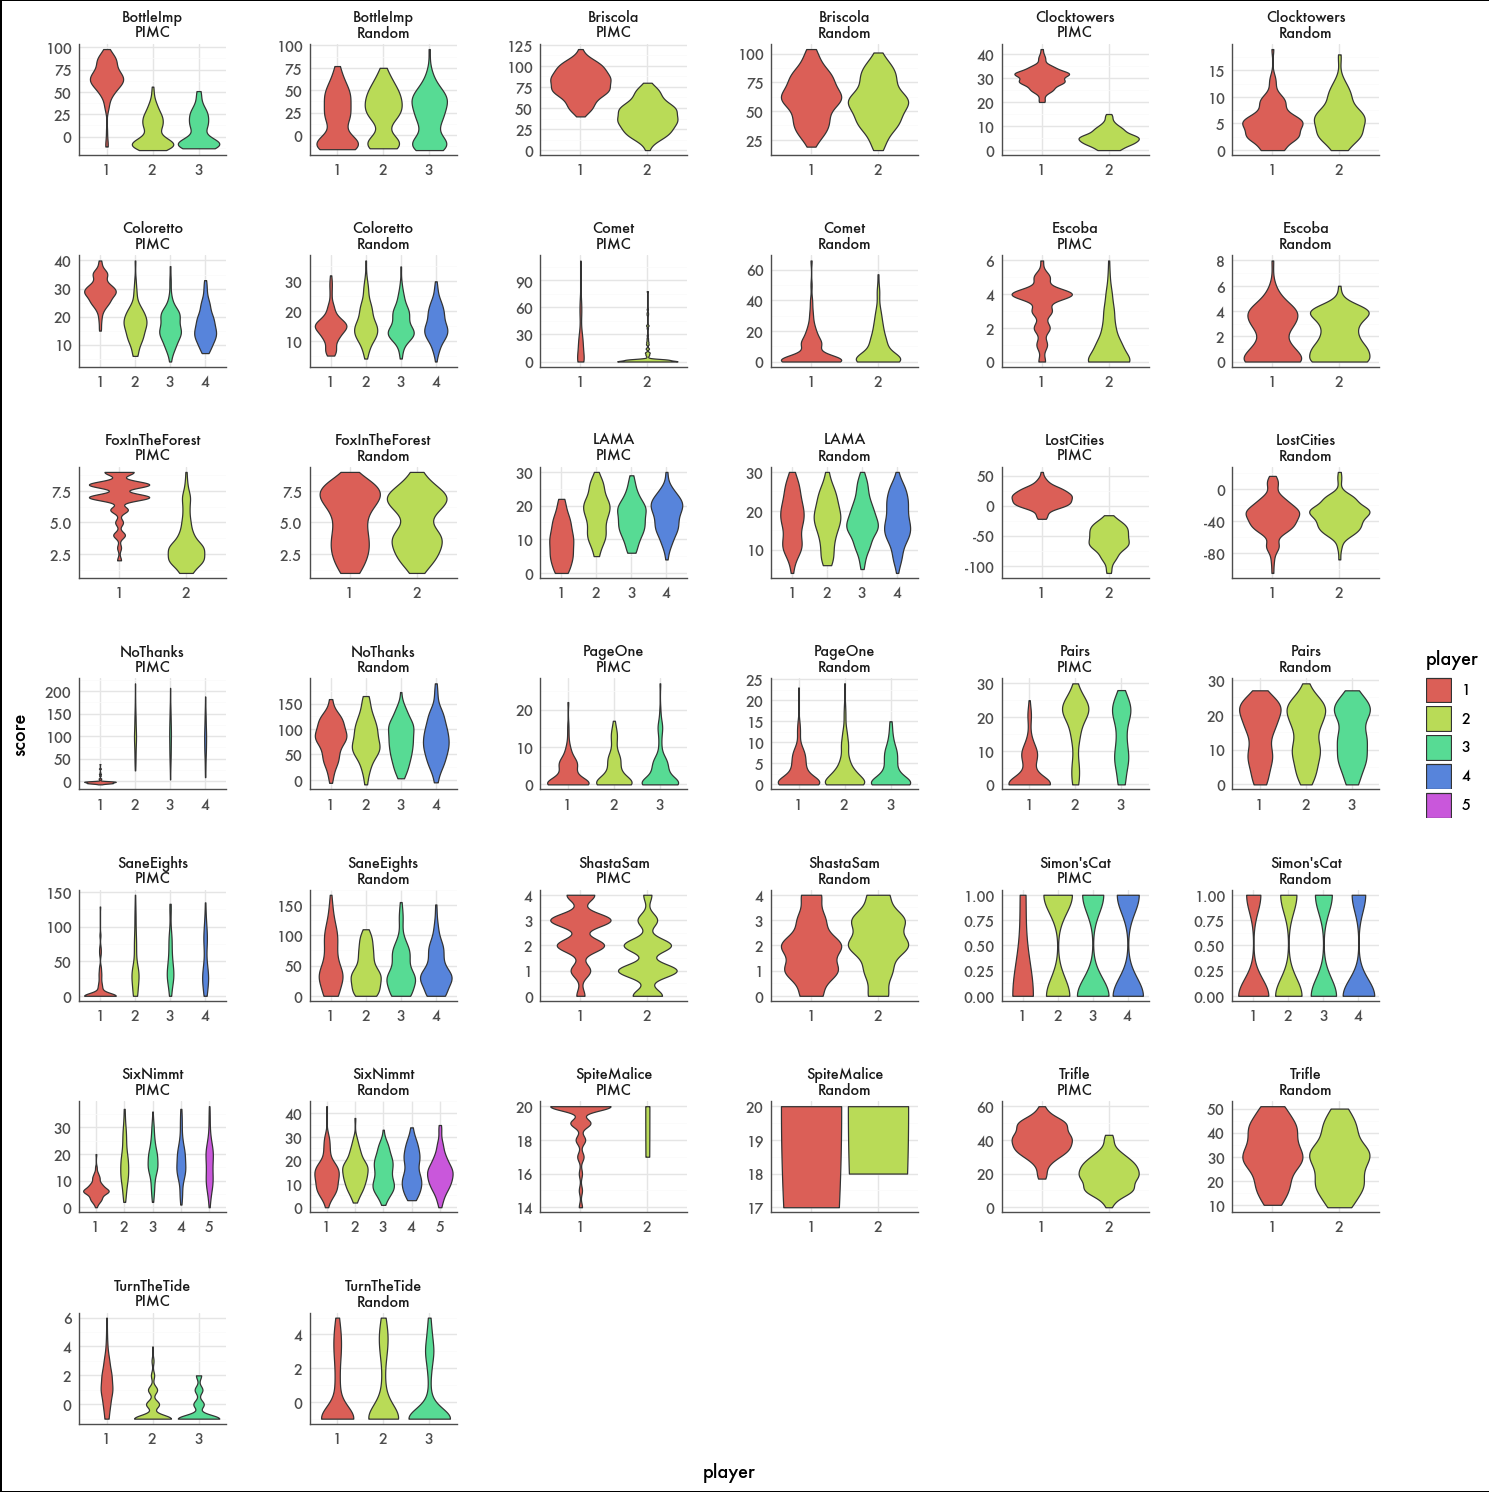

In [1047]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 15))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("Scores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Scores.png


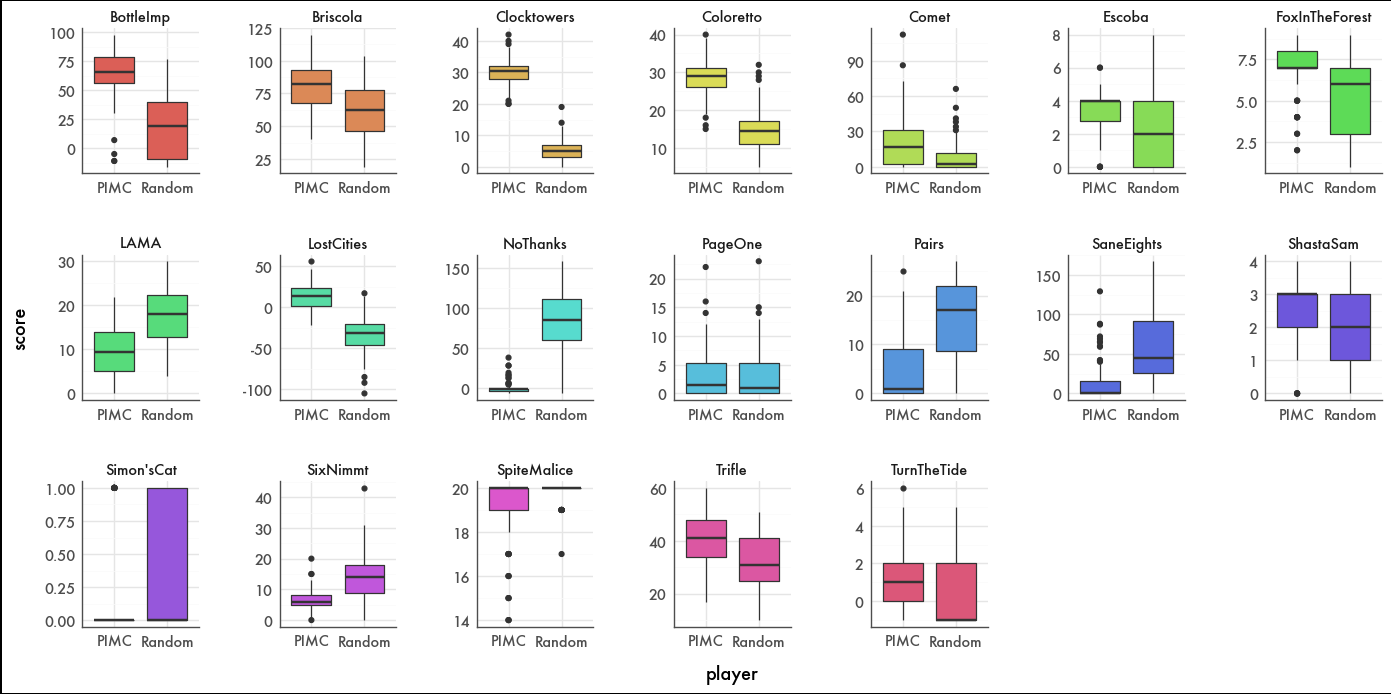

In [1049]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="game"))
 + geom_boxplot()
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("Scores.png")
splot.show()

# Spread

In [1065]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/spread.csv")
    gf["game"] = row["game"]
    if row["game"] == "Schwimmen":
        gf["spread"] = gf["spread"] / 2.0
    if first:
        spreadframe = gf
        first = False
    else:
        spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)


In [1066]:
spreadframe

,game,numPlayers,ai,run,pmove,player,spread
0,ShastaSam,2,PR,0,0,0,0.18
1,ShastaSam,2,PR,0,1,0,0.34
2,ShastaSam,2,PR,0,2,0,0.00
3,ShastaSam,2,PR,0,3,0,0.19
4,ShastaSam,2,PR,0,4,0,0.00
...,...,...,...,...,...,...,...
2595,FoxInTheForest,2,PR,100,22,0,0.00
2596,FoxInTheForest,2,PR,100,23,0,0.00
2597,FoxInTheForest,2,PR,100,24,0,0.00
2598,FoxInTheForest,2,PR,100,25,0,0.00


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


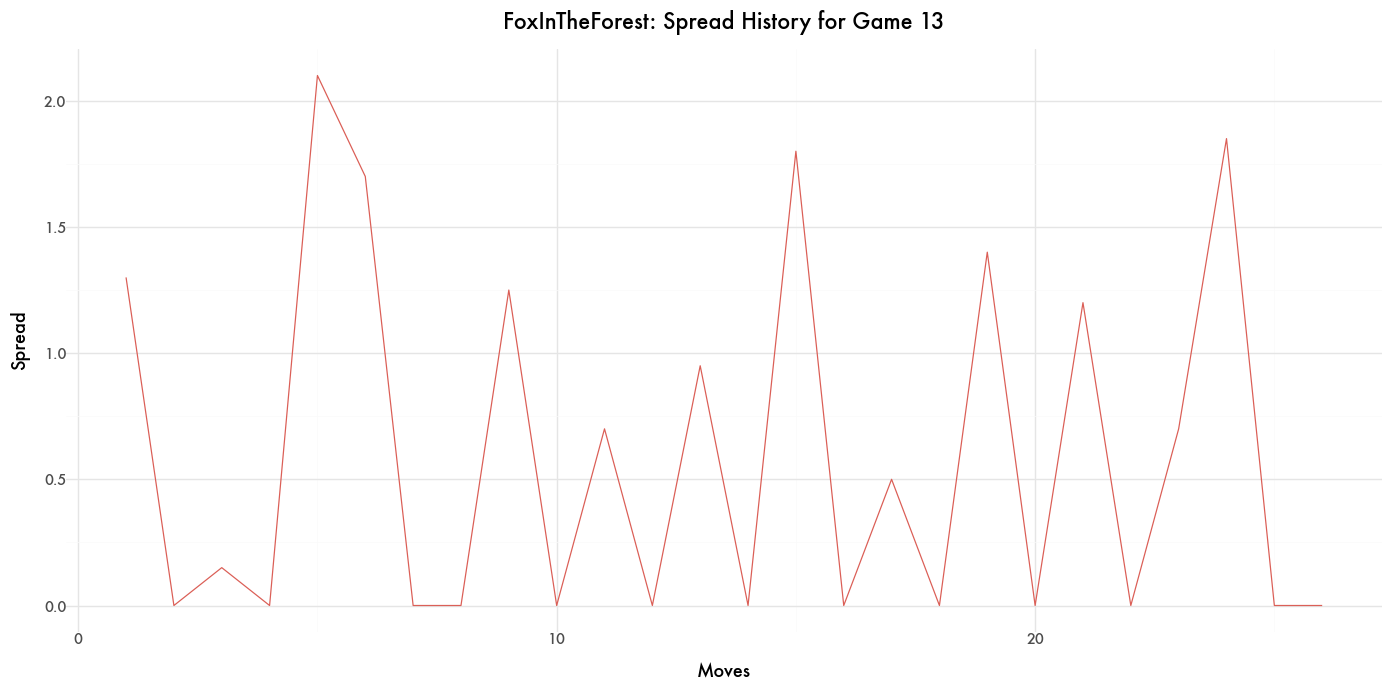

In [1067]:
game = "FoxInTheForest"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


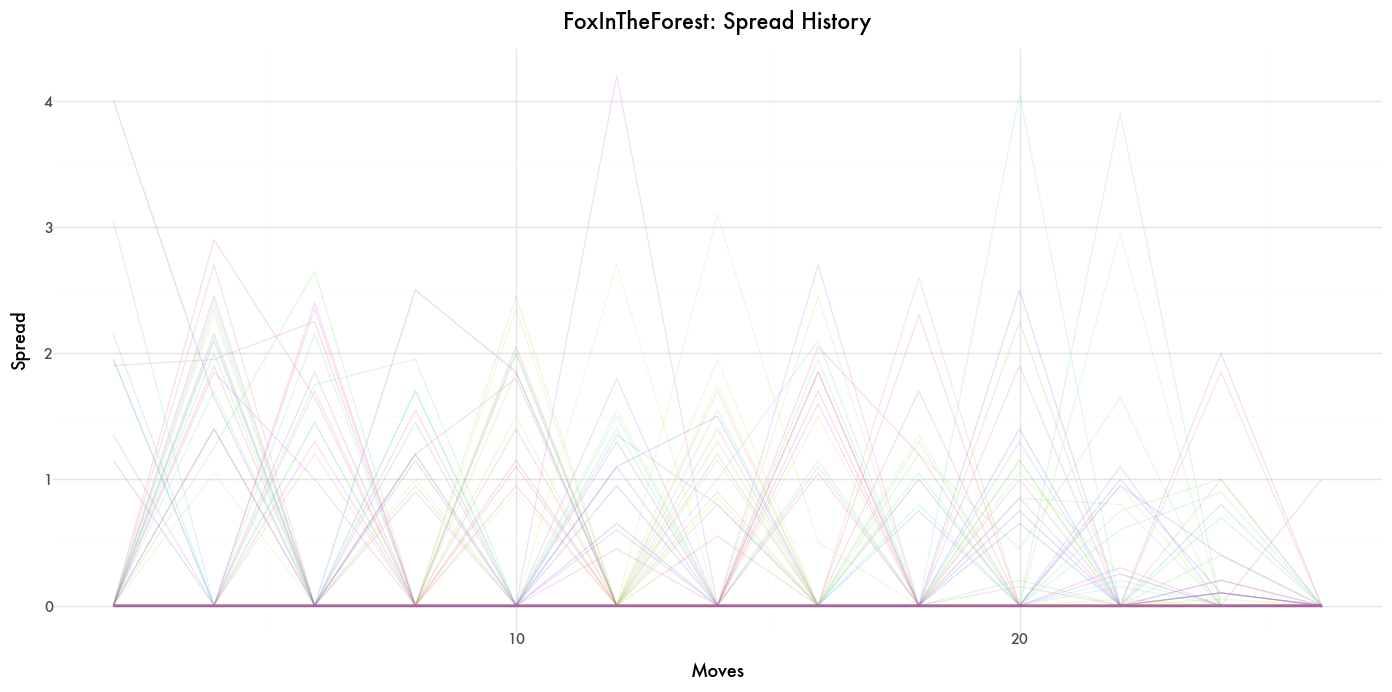

In [1068]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [1069]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,run,pmove,player,spread
0,FoxInTheForest,2,PR,1,1,0,1.35
1,FoxInTheForest,2,PR,1,2,0,0.00
2,FoxInTheForest,2,PR,1,3,0,2.70
3,FoxInTheForest,2,PR,1,4,0,0.00
4,FoxInTheForest,2,PR,1,5,0,1.50
...,...,...,...,...,...,...,...
2595,FoxInTheForest,2,PR,100,22,0,0.00
2596,FoxInTheForest,2,PR,100,23,0,0.00
2597,FoxInTheForest,2,PR,100,24,0,0.00
2598,FoxInTheForest,2,PR,100,25,0,0.00


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


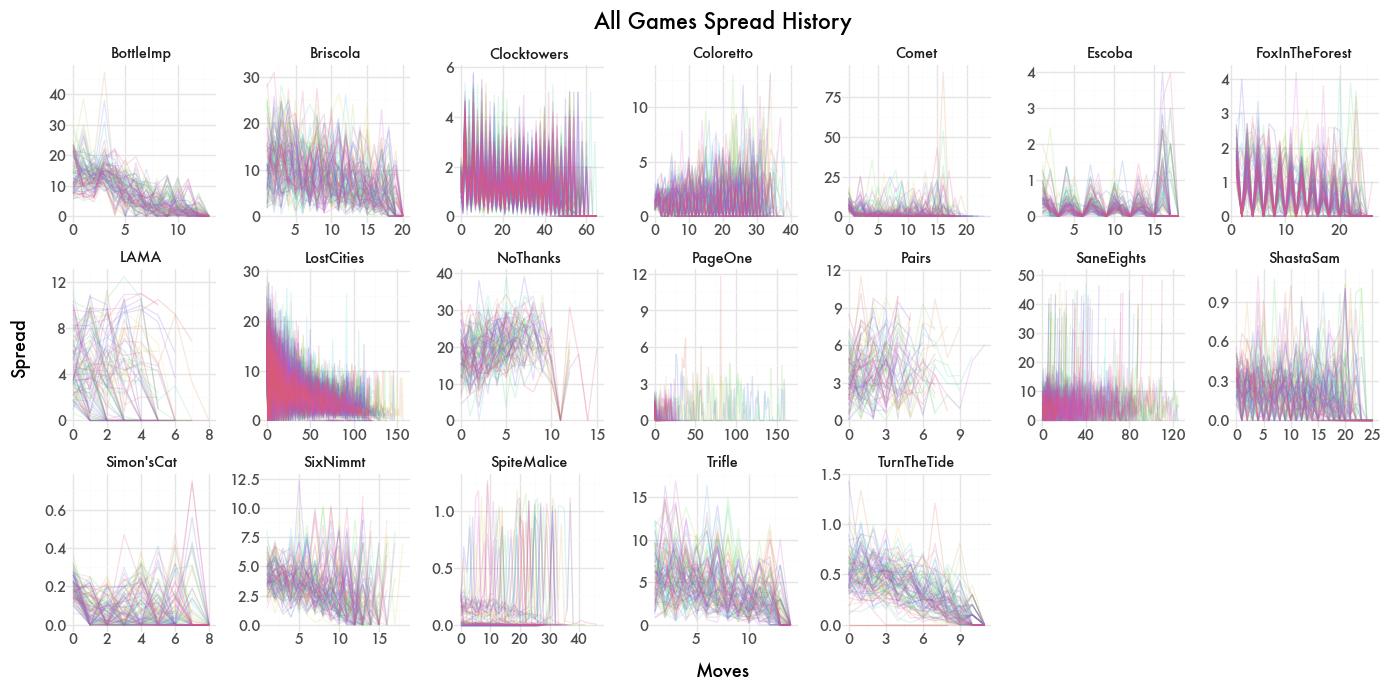

In [1070]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title="All Games Spread History")
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [1071]:
first = True
for index, row in gameframe.iterrows():
    #gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
    gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "PPPPPP" + "/lead.csv")
    gf["game"] = row["game"]
    if first:
        leadframe = gf
        first = False
    else:
        leadframe = pd.concat([leadframe, gf])


In [1072]:
leadframe["player"] = leadframe["player"].astype(str)
leadframe["run"] = leadframe["run"].astype(str)
leadframe["rank"] = leadframe["rank"].astype(str)
leadframe[leadframe["game"] == "SixNimmt"]

,game,numPlayers,ai,run,move,recorder,player,score,rankestimate,rank
0,SixNimmt,5,PRRRR,1,1,1,1,-12.65,0.6000,0.0
1,SixNimmt,5,PRRRR,1,1,1,2,-18.10,0.4375,2.0
2,SixNimmt,5,PRRRR,1,1,1,3,-17.95,0.3750,0.0
3,SixNimmt,5,PRRRR,1,1,1,4,-15.30,0.4875,4.0
4,SixNimmt,5,PRRRR,1,1,1,5,-12.25,0.6750,3.0
...,...,...,...,...,...,...,...,...,...,...
7355,SixNimmt,5,PRRRR,100,15,1,1,6.00,0.7500,1.0
7356,SixNimmt,5,PRRRR,100,15,2,2,4.00,1.0000,0.0
7357,SixNimmt,5,PRRRR,100,15,3,3,20.00,0.2500,3.0
7358,SixNimmt,5,PRRRR,100,15,4,4,18.00,0.5000,2.0


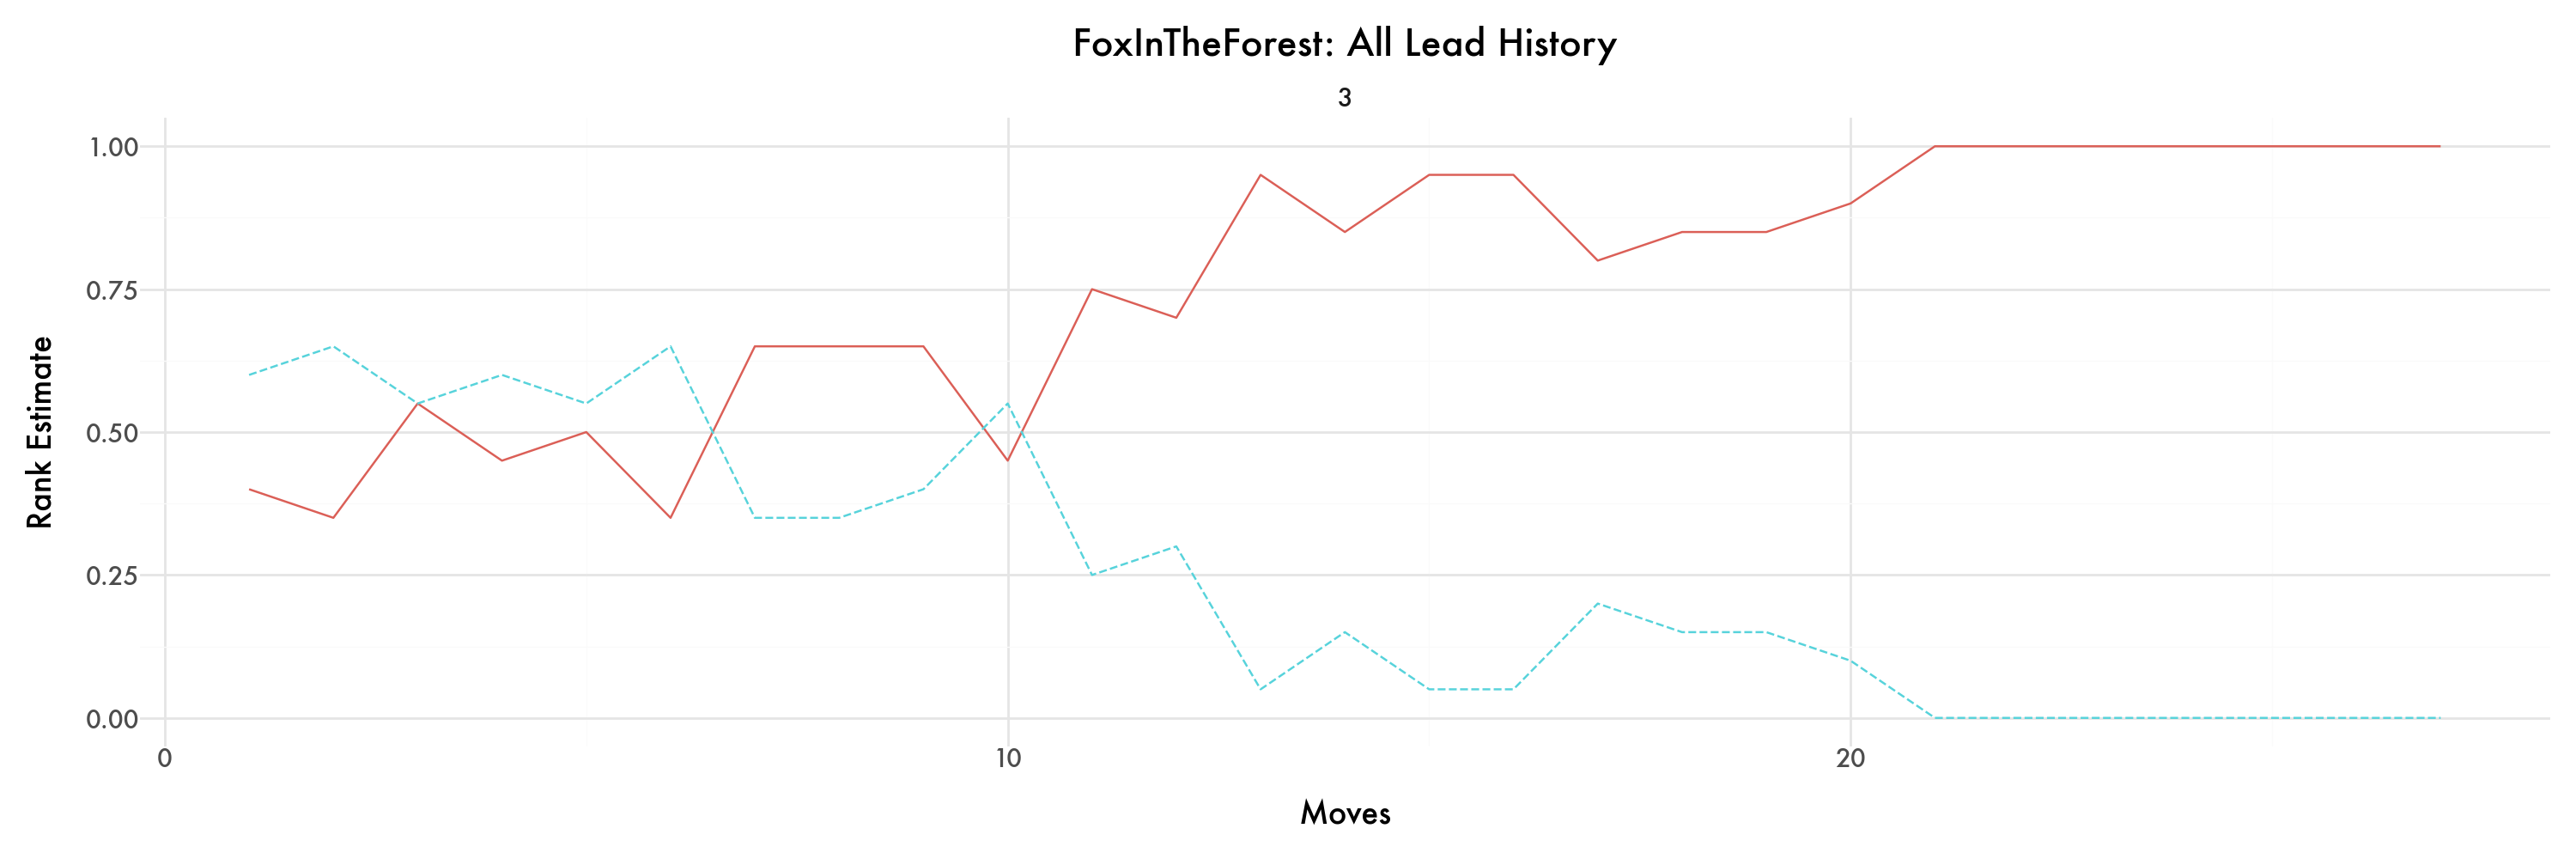

In [1073]:
game = "FoxInTheForest"
iter="3"
(ggplot(leadframe[(leadframe["game"] == game) & (leadframe["run"]== iter)], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_line(aes(linetype="rank"))
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(15, 5))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

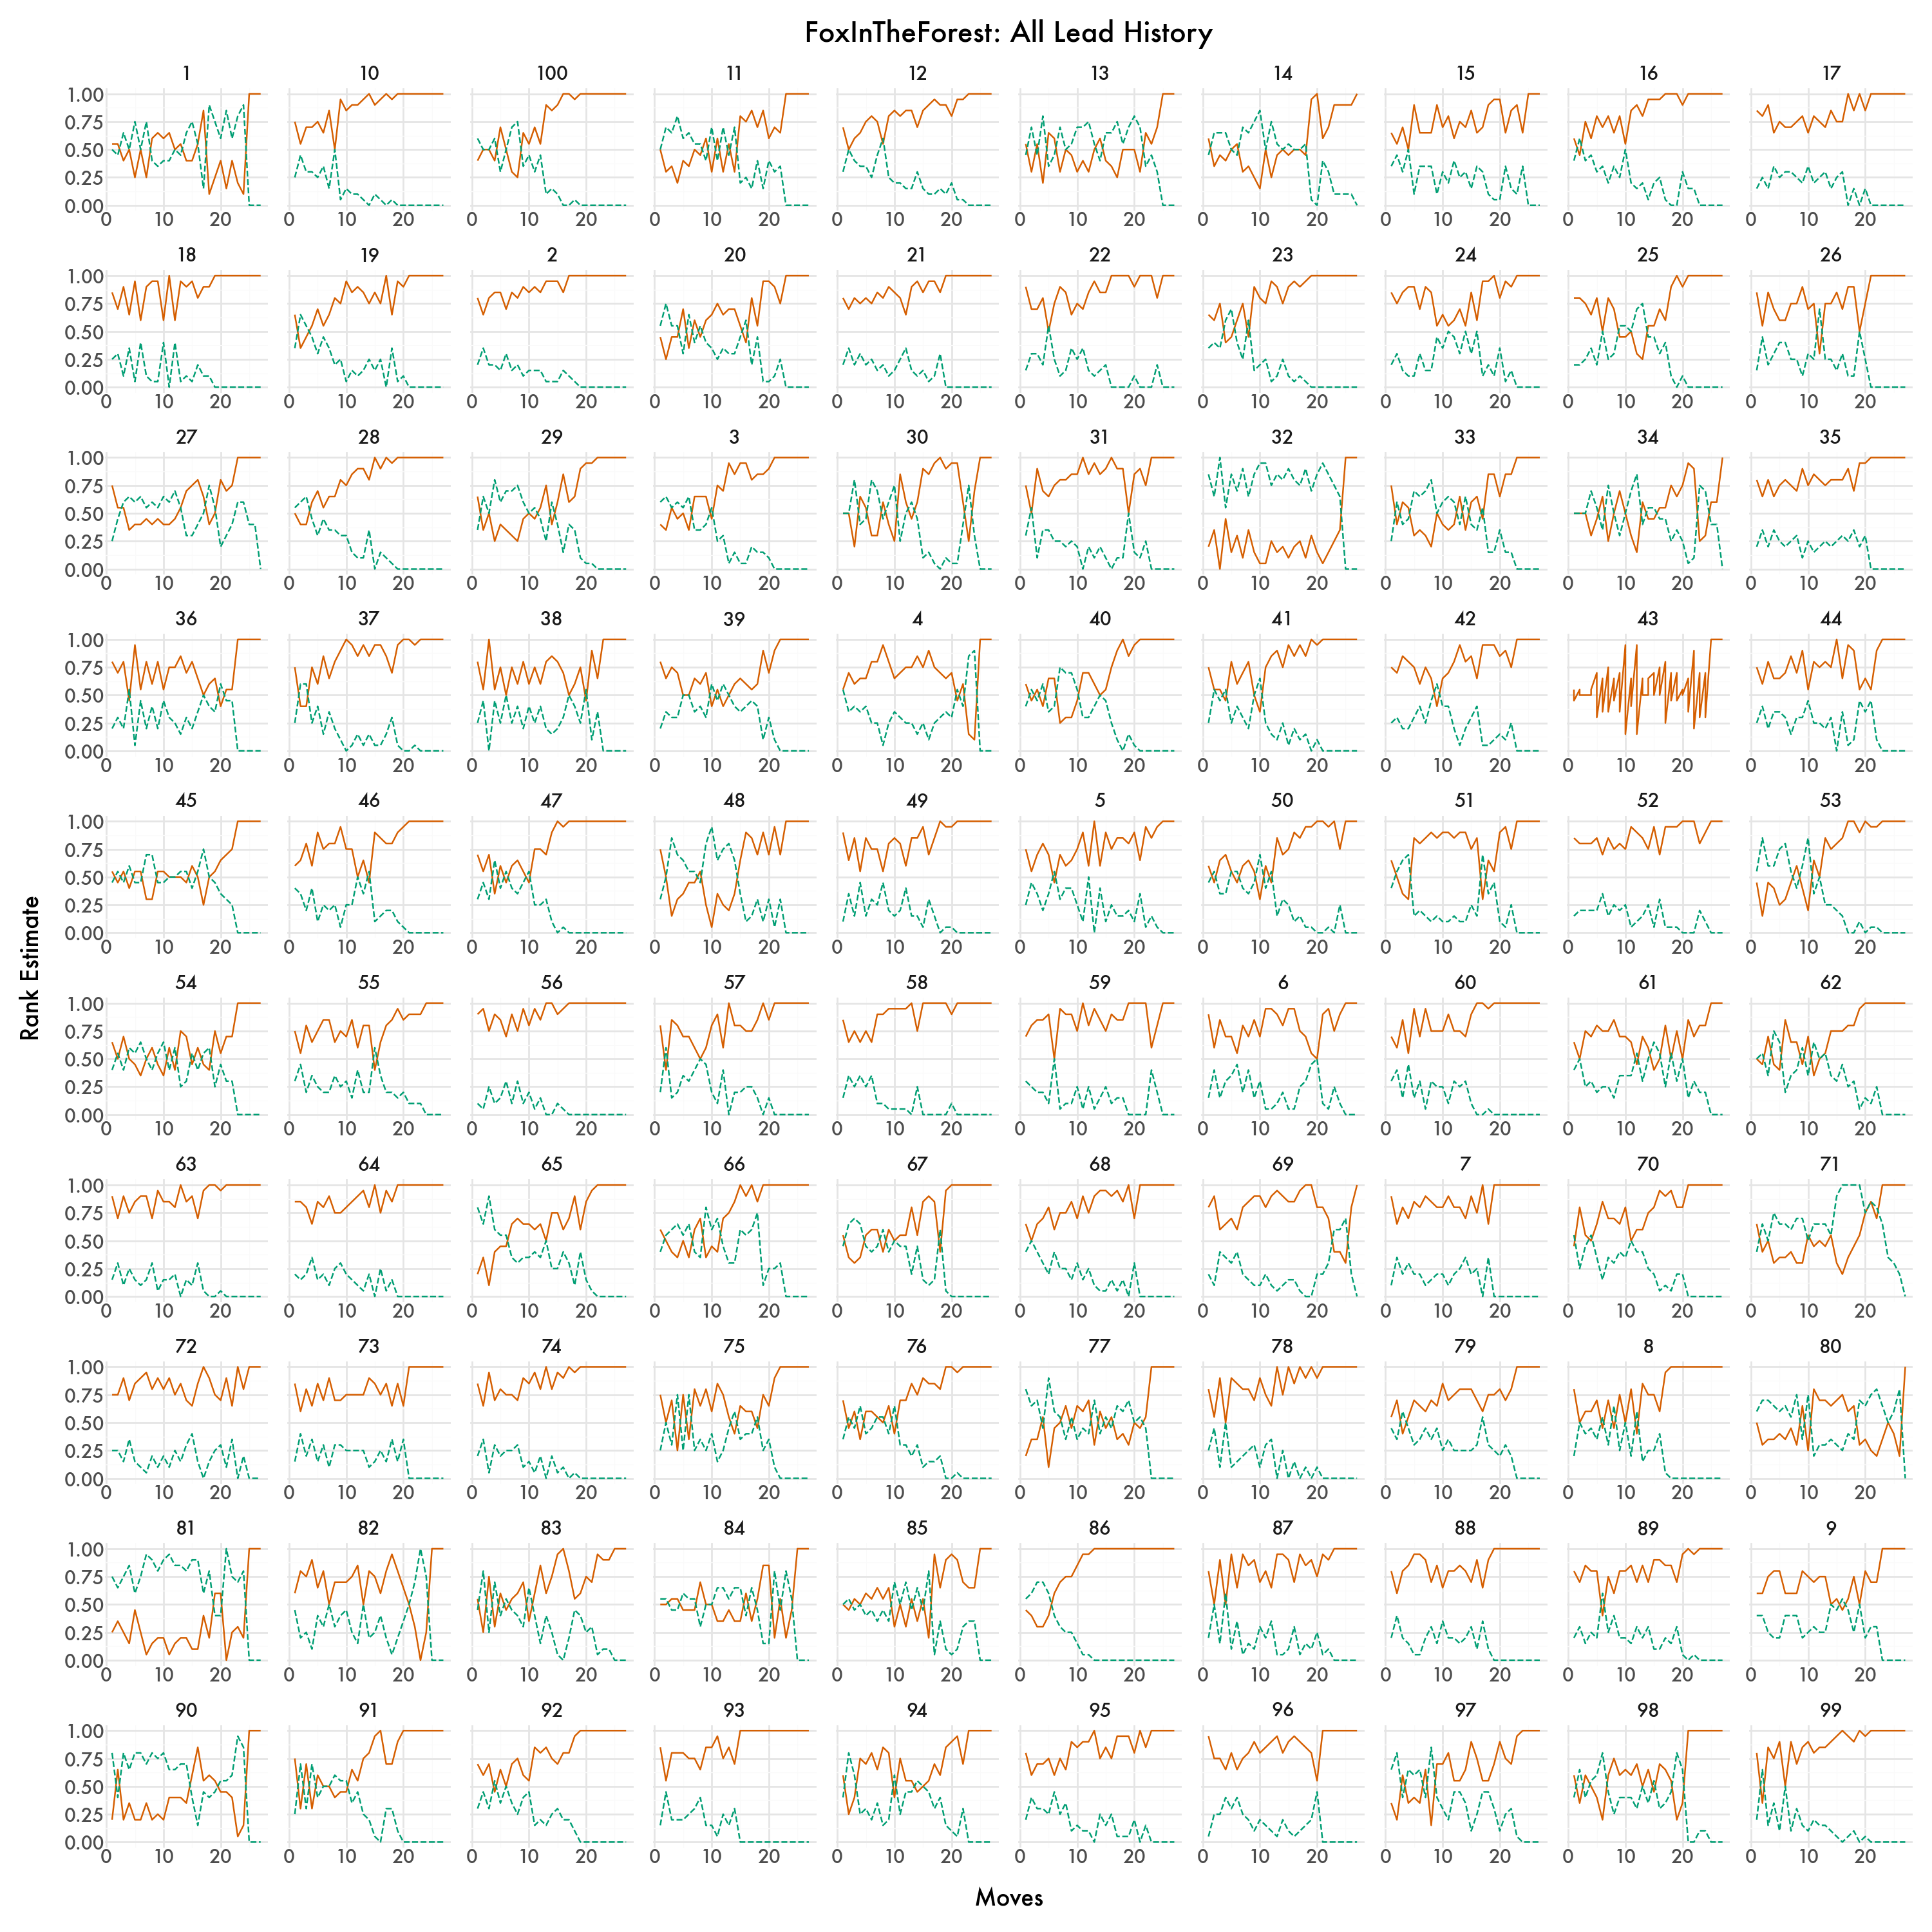

In [1074]:
(ggplot(leadframe[(leadframe["game"] == game)], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_line(aes(linetype="rank"))
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
 + scale_colour_manual(values=cbbPalette)
)

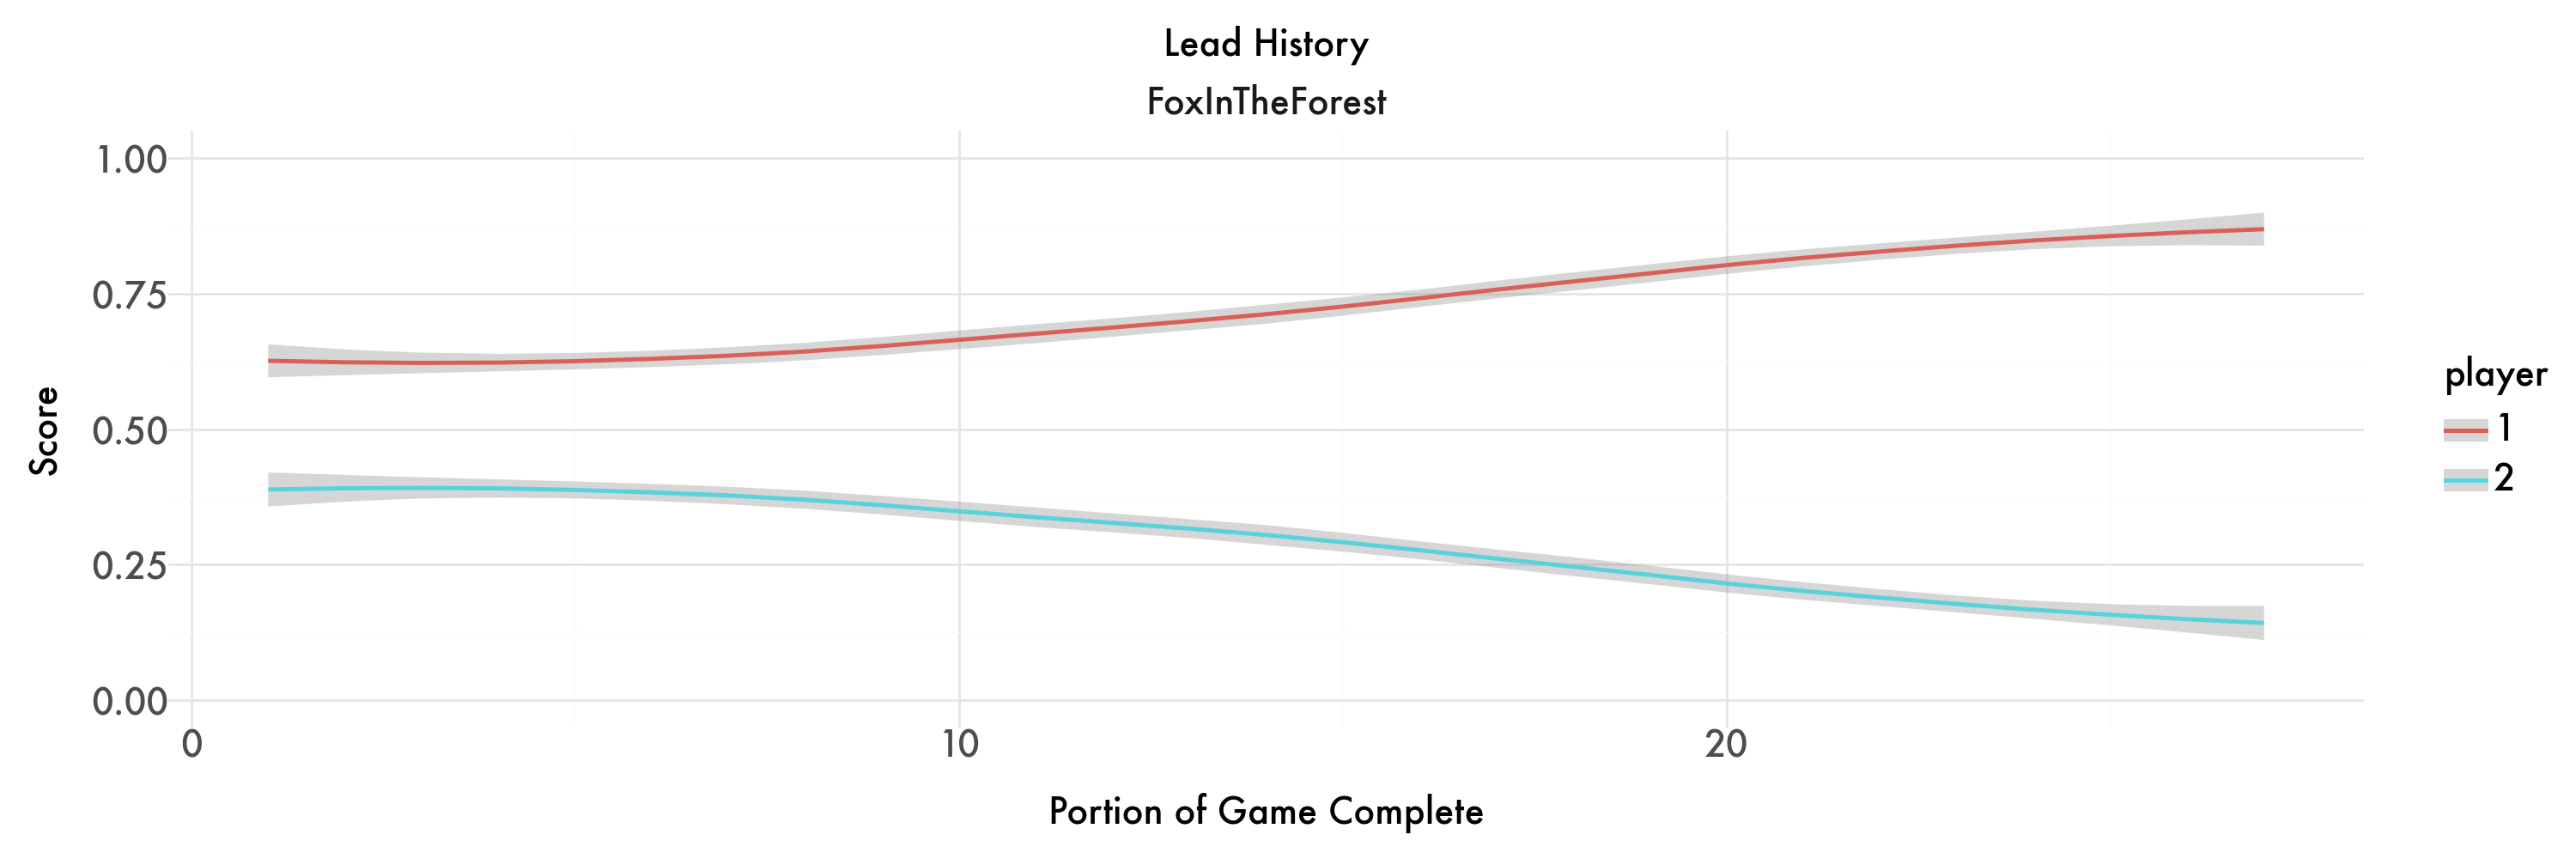

In [1076]:
(ggplot(leadframe[(leadframe["game"] == game)], 
       aes(x="move", y="rankestimate", color="player"))
 + geom_smooth(method="loess")
 + ylim(0, 1)
 + facet_wrap("game")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(15, 5), text=element_text(size=15))
 + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Lead.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 66 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 66 rows containing missing values.


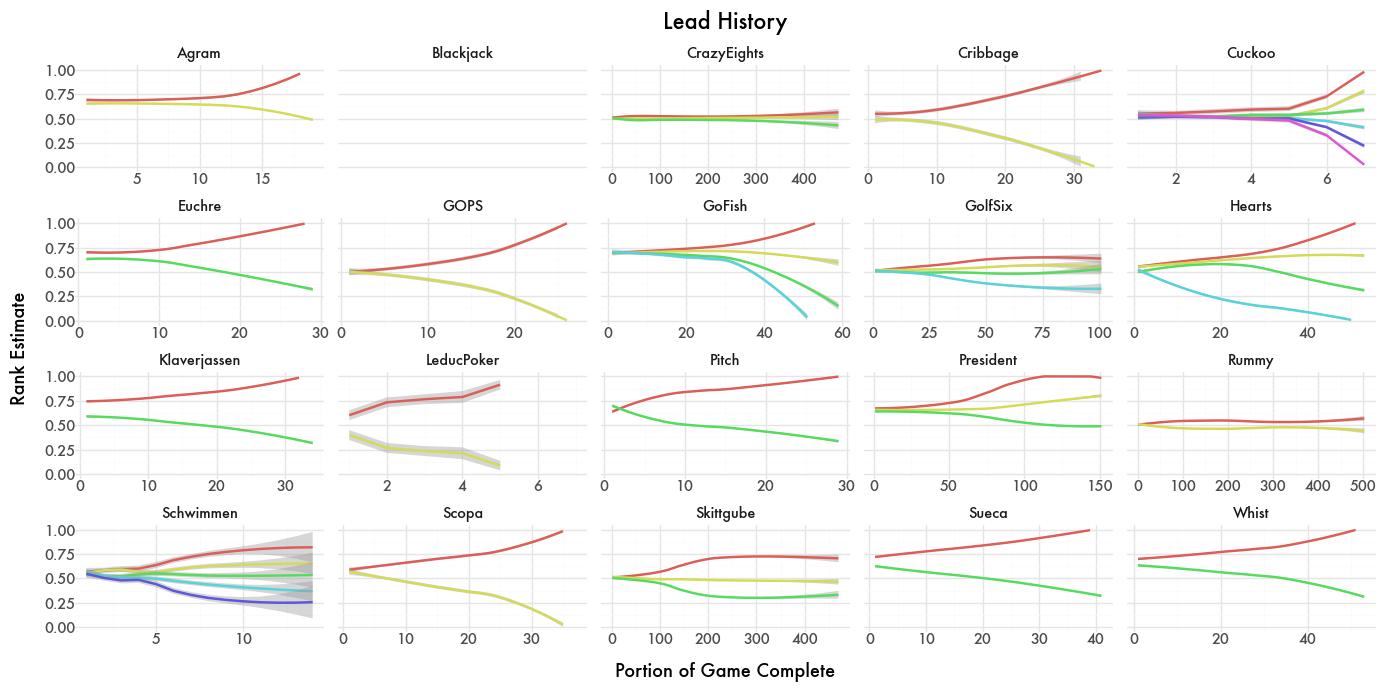

In [966]:
lplot = (ggplot(leadframe[(leadframe["game"] == "LeducPoker") | (leadframe["game"] == "Rummy") | (leadframe["game"] == "President") | (leadframe["game"] == "GoFish") | (leadframe["game"] == "CrazyEights") | (leadframe["game"] == "Agram") | (leadframe["game"] == "Skittgube") | (leadframe["game"] == "GolfSix")| (leadframe["game"] == "Schwimmen")| (leadframe["game"] == "Whist")| (leadframe["game"] == "Klaverjassen")| (leadframe["game"] == "Euchre")| (leadframe["game"] == "Pitch")| (leadframe["game"] == "Cuckoo")| (leadframe["game"] == "GOPS")| (leadframe["game"] == "Scopa")| (leadframe["game"] == "Hearts") | (leadframe["game"] == "Blackjack")| (leadframe["game"] == "Cribbage")| (leadframe["game"] == "Sueca")], 
       aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess")
 + ylim(0, 1)
 + facet_wrap("game", scales="free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Portion of Game Complete', y='Rank Estimate', title="Lead History")
)
lplot.save("Lead.png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Lead.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 5 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 5 rows containing missing values.


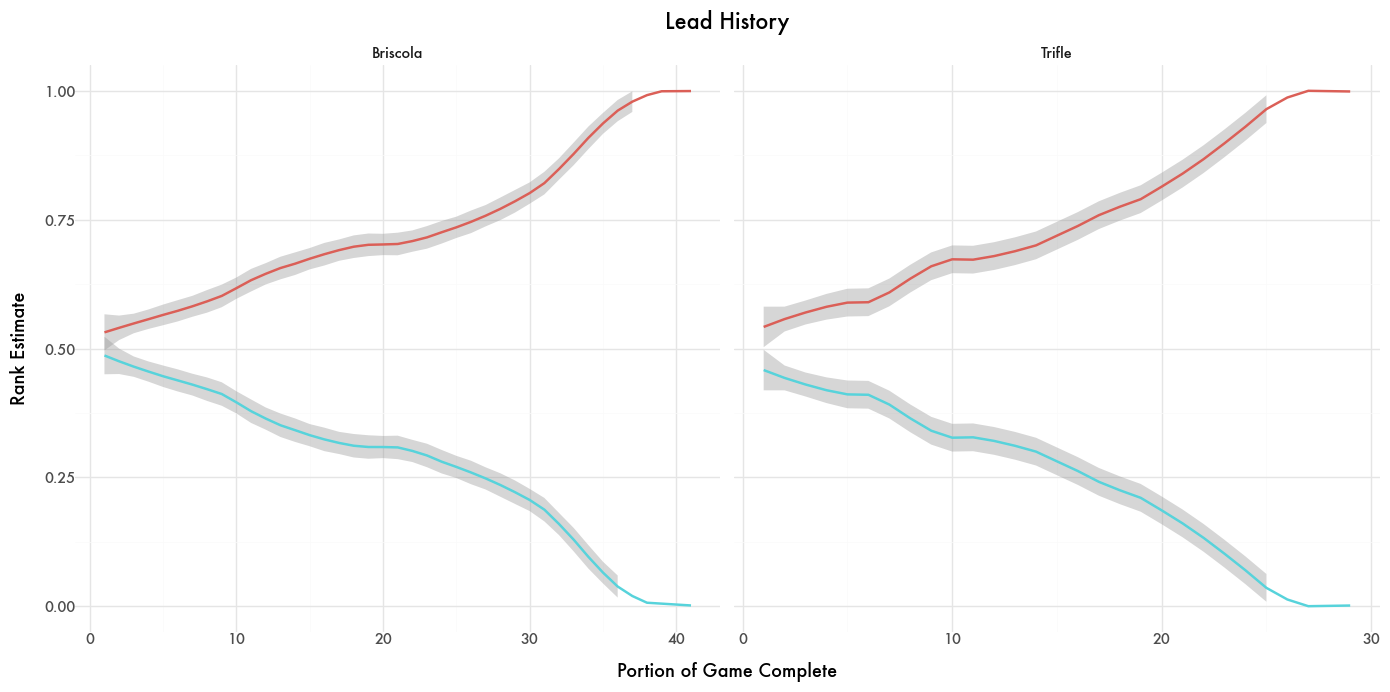

In [915]:
lplot = (ggplot(leadframe, aes(x="move", y="rankestimate", color="rank"))
 + geom_smooth(method="loess", span=0.3)
 + ylim(0, 1)
 + facet_wrap("game", scales="free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Portion of Game Complete', y='Rank Estimate', title="Lead History")
)
lplot.save("Lead.png")
lplot.show()